In [ ]:
# Import necessary packages
import pandas as pd
import numpy as np
import umap
import hdbscan
import matplotlib.pyplot as plt
from sklearn.manifold import trustworthiness
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
    OrdinalEncoder
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (adjusted_rand_score, accuracy_score, roc_auc_score,
                             average_precision_score, precision_recall_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, logrank_test
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# Set a random seed for reproducibility
random_state = 492026

# Read in the data
df = pd.read_csv('../data/lung_cancer_data.csv')

In [2]:
# Consolidate metastasis columns
metastasis = []
for i in range(df.shape[0]):
    mets = df[["mets_at_dx_bone", "mets_at_dx_brain", "mets_at_dx_distant_ln", "mets_at_dx_liver", 
               "mets_at_dx_lung", "mets_at_dx_other"]].iloc[i].tolist()
    if "Yes" in mets:
        metastasis.append(1)
    else:
        metastasis.append(0)
df['metastasis'] = pd.Series(metastasis)
df = df.drop(columns=["mets_at_dx_bone", "mets_at_dx_brain", "mets_at_dx_distant_ln",
                   "mets_at_dx_liver", "mets_at_dx_lung", "mets_at_dx_other"])

# Recode NAs
df['rx_summ_chemo'] = df['rx_summ_chemo'].fillna("No Chemo")
df['rx_summ_immunotherapy'] = df['rx_summ_immunotherapy'].fillna("No Immuno")

df

,year_of_diagnosis,dx_lastcontact_death_months,puf_vital_status,puf_case_id,puf_facility_id,facility_type_cd,facility_location_cd,age,sex,race,...,laterality,histology,regional_nodes_positive,analytic_stage_group,tumor_size_summary_2016,rx_summ_surg_prim_site,rx_summ_chemo,rx_summ_immunotherapy,rx_summ_surgrad_seq,metastasis
0,2018,1.120000,Dead,D00002e7d-bb34-46e6-849e-6c4f0acef147,RNYCFBVPLK,Community Cancer Program,South Atlantic,71.0,Male,White,...,Origin of primary is left,Squamous cell carcinoma,No nodes were examined,Stage IV,94.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,1
1,2019,34.070000,Dead,D00002f04-3dd7-4234-bb33-84f3a20b86c9,PSAHKJHEIG,Comprehensive Community Cancer Program,Pacific,90.0,Female,Black,...,Origin of primary is right,Squamous cell carcinoma,No nodes were examined,Stage IV,28.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,1
2,2019,21.450001,Dead,D0000690b-4418-4162-bc8e-2d62701c93ca,GQSMCSUAOK,Community Cancer Program,East North Central,80.0,Female,White,...,Origin of primary is right,Squamous cell carcinoma,No nodes were examined,Stage III,12.0,No surgery,Multiagent chemotherapy,No Immuno,No radiation therapy and/or surgical procedures,0
3,2022,1.380000,Dead,D00006b9c-dcb3-4535-a4fd-e20bd886fc9d,AUUCOIRDTB,Comprehensive Community Cancer Program,South Atlantic,80.0,Female,Other,...,Origin of primary is left,Squamous cell carcinoma,No nodes were examined,Stage IV,87.0,No surgery,No Chemo,Yes (first course therapy),No radiation therapy and/or surgical procedures,1
4,2019,40.049999,Alive,D00006dce-2eb8-498e-a6bc-da673b7a434e,CFHJPZWJNY,Integrated Network Cancer Program,West South Central,57.0,Female,White,...,Origin of primary is left,Adenocarcinoma,No nodes were examined,Stage III,70.0,No surgery,Multiagent chemotherapy,Yes (first course therapy),No radiation therapy and/or surgical procedures,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414470,2022,30.820000,Alive,Dffff6eb3-09cf-433b-9c8c-165143c8ecc8,VHTPYZBLEB,Integrated Network Cancer Program,East North Central,78.0,Male,White,...,Origin of primary is left,Adenocarcinoma,No nodes were examined,Stage I,14.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,0
414471,2020,7.360000,Dead,Dffff7a97-fd34-438d-b5b9-ca1930c78679,TXEIDOZHLI,Integrated Network Cancer Program,South Atlantic,75.0,Male,White,...,Origin of primary is right,Squamous cell carcinoma,All nodes examined are negative,Stage III,103.0,Pneumonectomy,Multiagent chemotherapy,Yes (first course therapy),No radiation therapy and/or surgical procedures,0
414472,2018,12.160000,Dead,Dffff8d6c-a1cd-4085-9846-222b943a44d3,TVXWQGNICT,Comprehensive Community Cancer Program,Pacific,61.0,Female,White,...,Origin of primary is left,Adenocarcinoma,No nodes were examined,Stage IV,46.0,No surgery,Multiagent chemotherapy,Yes (first course therapy),No radiation therapy and/or surgical procedures,1
414473,2022,1.870000,Dead,Dffffabfc-6747-43e7-86c7-9cf043363c9f,UMUHJVXWPB,Integrated Network Cancer Program,West South Central,75.0,Male,Other,...,Origin of primary is right,Adenocarcinoma,No nodes were examined,Stage IV,70.0,No surgery,No Chemo,No Immuno,No radiation therapy and/or surgical procedures,1


In [3]:
continuous_cols = [
    "age",                       # fairly normal/symmetric
    "crowfly",                   # very right skewed
    "tumor_size_summary_2016"    # pretty right skewed
]
ordinal_cols = [
    "ur_cd_23",
    "analytic_stage_group",
    "cdcc_total_best",
    "no_hsd_quar_2020",
    "med_inc_quar_2020",
    "regional_nodes_positive"
]
ordinal_categories = [
    [str(float(i)) for i in range(1, 10)],                              # ur_cd_23
    ["Stage I", "Stage II", "Stage III", "Stage IV"],                   # analytic_stage_group
    ["0", "1", "2", ">=3"],                                             # cdcc_total_best
    ["< 5.0%", "5.0%-9.0%", "9.1%-15.2%", ">= 15.3%"],                  # no_hsd_quar_2020
    ["< $46,277", "$46,227-$57,856", "$57,857-$74,062", ">= $74,063"],  # med_inc_quar_2020
    ["No nodes were examined", "All nodes examined are negative",
     "Positive aspiration of lymph node(s)", "1-10", "11-20", "21+"]    # regional_nodes_positive
]
nominal_cols = [
    "facility_type_cd",
    "facility_location_cd",
    "sex",
    "race",
    "spanish_hispanic_origin",
    "metastasis",
    "insurance_status",
    "primary_site",
    "laterality",
    "histology",
    "rx_summ_surg_prim_site",
    "rx_summ_surgrad_seq",
    "rx_summ_chemo",
    "rx_summ_immunotherapy"
]

In [4]:
# Preprocess the data

log1p_transformer = FunctionTransformer(np.log1p, validate=True)

preprocessor = ColumnTransformer(
    transformers=[
        # Continuous: log-transform + standardize
        ("cont", Pipeline(steps=[("log", log1p_transformer),
                                 ("scale", StandardScaler())]),
                 ["crowfly", "tumor_size_summary_2016"]),
        ("age", StandardScaler(), ["age"]),
        # Ordinal categorical
        ("ord", OrdinalEncoder(categories=ordinal_categories), ordinal_cols),
        # Nominal categorical
        ("nom", OneHotEncoder(handle_unknown="ignore"),
                nominal_cols),
    ],
    remainder="drop"
)



# Apply preprocessing
X_features = df.drop(columns=['year_of_diagnosis', 'dx_lastcontact_death_months',
                              'puf_vital_status', 'puf_case_id', 'puf_facility_id'])
X_processed = preprocessor.fit_transform(X_features)

In [5]:
# Obtain UMAP embedding and calculate trustworthiness score on sub sample
                
umap_model = umap.UMAP(
n_components=10,        
n_neighbors=30,          
min_dist=0.1,
random_state=random_state)

X_umap = umap_model.fit_transform(X_processed)

rng = np.random.default_rng(random_state)
idx = rng.choice(
    X_processed.shape[0],
    size=10000,
    replace=False
)

X_sub = X_processed[idx]
X_umap_sub = X_umap[idx]

trust = trustworthiness(
    X_sub,
    X_umap_sub,
    n_neighbors=30
)

print(f"Trust (subsampled): {trust:.4f}")

/Users/cromacair/Desktop/STAT 486/Final Project/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Trust (subsampled): 0.9712


In [9]:
# Perfrom HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=100,      
    min_samples=200,            
    metric="euclidean",
    cluster_selection_method="eom"
)
labels = clusterer.fit_predict(X_umap)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_frac = np.mean(labels == -1)
print(f"Clusters found: {n_clusters}")
print(f"Noise fraction: {noise_frac:.3f}")

# Cluster persistence (HDBSCAN-specific)
cluster_labels = np.array(sorted(set(labels) - {-1}))
persistence = clusterer.cluster_persistence_
persistence_df = pd.DataFrame({
    "cluster": cluster_labels,
    "persistence": persistence
}).sort_values(by="persistence", ascending=False)
print(persistence_df)

# Size distribution
size_counts = pd.Series(labels).value_counts().sort_index()
cluster_sizes = size_counts.drop(-1, errors='ignore')
noise_size = size_counts.get(-1, 0)
size_df = pd.DataFrame({
    "cluster": cluster_sizes.index,
    "size": cluster_sizes.values,
    "proportion": cluster_sizes.values / len(labels)
}).sort_values(by="size", ascending=False)
print(size_df)

# Adjusted Rand Index (stability via resampling)
idx = np.arange(len(X_umap))
aris = []
for seed in [0, 1, 2, 3, 4]:
    idx_sub = resample(idx, replace=False, n_samples=int(0.8 * len(idx)), random_state=seed)
    X_sub = X_umap[idx_sub]
    clusterer_sub = hdbscan.HDBSCAN(
        min_cluster_size=500,
        min_samples=50,
        metric="euclidean",
        cluster_selection_method="eom"
    )
    labels_sub = clusterer_sub.fit_predict(X_sub)
    labels_full_sub = labels[idx_sub]
    mask = (labels_sub != -1) & (labels_full_sub != -1)
    if np.sum(mask) > 0:
        ari = adjusted_rand_score(labels_full_sub[mask], labels_sub[mask])
        aris.append(ari)
print(f"\nARI mean: {np.mean(aris):.3f}")
print(f"ARI std: {np.std(aris):.3f}")

Clusters found: 9
Noise fraction: 0.008
   cluster  persistence
1        1     0.721481
2        2     0.175774
0        0     0.148890
3        3     0.106637
6        6     0.095471
4        4     0.074676
5        5     0.073756
8        8     0.039400
7        7     0.038071
   cluster    size  proportion
8        8  101982    0.246051
3        3  100930    0.243513
7        7   94920    0.229013
0        0   48398    0.116769
2        2   23078    0.055680
5        5   21526    0.051936
6        6   19491    0.047026
1        1     385    0.000929
4        4     252    0.000608

ARI mean: 0.806
ARI std: 0.236


In [13]:
df.columns

Index(['year_of_diagnosis', 'dx_lastcontact_death_months', 'puf_vital_status',
       'puf_case_id', 'puf_facility_id', 'facility_type_cd',
       'facility_location_cd', 'age', 'sex', 'race', 'spanish_hispanic_origin',
       'insurance_status', 'no_hsd_quar_2020', 'med_inc_quar_2020', 'ur_cd_23',
       'crowfly', 'cdcc_total_best', 'primary_site', 'laterality', 'histology',
       'regional_nodes_positive', 'analytic_stage_group',
       'tumor_size_summary_2016', 'rx_summ_surg_prim_site', 'rx_summ_chemo',
       'rx_summ_immunotherapy', 'rx_summ_surgrad_seq', 'metastasis',
       'cluster'],
      dtype='str')

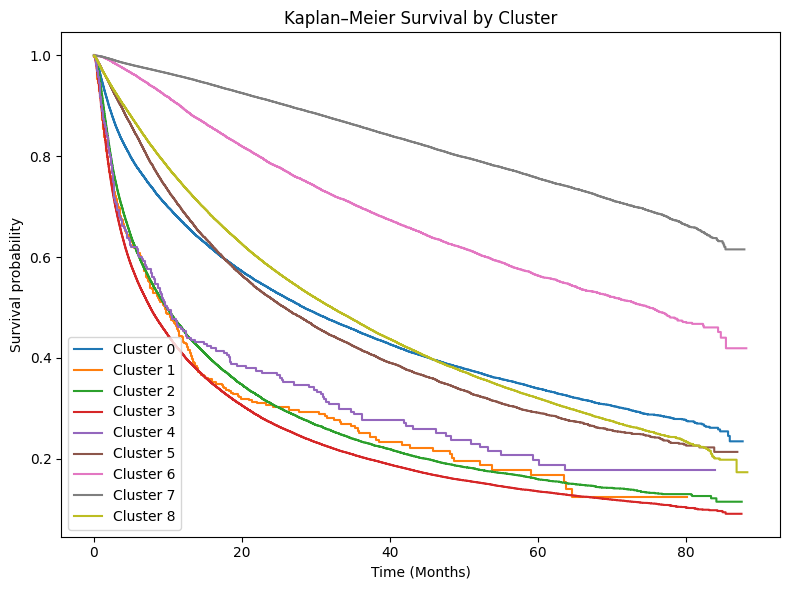

In [24]:
# Perform comparative survival analysis with cluster labels
df["cluster"] = labels

# Remove noise points
df_surv = df[df["cluster"] != -1].copy()

# Perform a cleaning step
df_surv['puf_vital_status_binary'] = df_surv["puf_vital_status"].map({'Dead':1, 'Alive':0})

# Plot KM curves by cluster label
kmf = KaplanMeierFitter()
plt.figure(figsize=(8, 6))
for cluster_id in sorted(df_surv["cluster"].unique()):
    mask = df_surv["cluster"] == cluster_id
    kmf.fit(
        durations=df_surv.loc[mask, "dx_lastcontact_death_months"],
        event_observed=df_surv.loc[mask, "puf_vital_status_binary"],
        label=f"Cluster {cluster_id}"
    )
    kmf.plot(ci_show=False)
plt.title("Kaplan–Meier Survival by Cluster")
plt.xlabel("Time (Months)")
plt.ylabel("Survival probability")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Perform a global log‑rank test
results = multivariate_logrank_test(
    df_surv["dx_lastcontact_death_months"],
    df_surv["cluster"],
    df_surv["puf_vital_status_binary"]
)
print(results)

# Perform pair-wise comparisons
pairwise_results = []
clusters_surv = sorted(df_surv["cluster"].unique())
for c1, c2 in combinations(clusters_surv, 2):
    g1 = df_surv[df_surv["cluster"] == c1]
    g2 = df_surv[df_surv["cluster"] == c2]
    res = logrank_test(
        g1["dx_lastcontact_death_months"], 
        g2["dx_lastcontact_death_months"],
        event_observed_A=g1["puf_vital_status_binary"],
        event_observed_B=g2["puf_vital_status_binary"]
    )
    pairwise_results.append({
        "cluster_1": c1,
        "cluster_2": c2,
        "p_value": res.p_value
    })
pairwise_df = pd.DataFrame(pairwise_results)
# FDR (Benjamini–Hochberg) correction
pairwise_df["p_adj"] = multipletests(
    pairwise_df["p_value"],
    method="fdr_bh"
)[1]
pairwise_df = pairwise_df.sort_values("p_adj")
pairwise_df.reset_index(inplace=True, drop=True)
significance = []
for i in range(pairwise_df.shape[0]):
    if pairwise_df['p_adj'].iloc[i] < 0.001:
        significance.append('***')
    elif pairwise_df['p_adj'].iloc[i] < 0.01:
        significance.append('**')
    elif pairwise_df['p_adj'].iloc[i] < 0.05:
        significance.append('*')
    elif pairwise_df['p_adj'].iloc[i] < 0.1:
        significance.append('.')
    else:
        significance.append(' ')
pairwise_df['significance'] = pd.Series(significance)
pairwise_df

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 8
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
      113991.98 <0.005       inf


,cluster_1,cluster_2,p_value,p_adj,significance
0,2,5,0.000000e+00,0.000000e+00,***
1,6,7,0.000000e+00,0.000000e+00,***
2,5,7,0.000000e+00,0.000000e+00,***
3,5,6,0.000000e+00,0.000000e+00,***
4,3,8,0.000000e+00,0.000000e+00,***
5,3,7,0.000000e+00,0.000000e+00,***
6,3,6,0.000000e+00,0.000000e+00,***
7,3,5,0.000000e+00,0.000000e+00,***
8,2,8,0.000000e+00,0.000000e+00,***
9,2,7,0.000000e+00,0.000000e+00,***


In [31]:
# Fit a Cox Proportional Hazards Model with cluster as the covariate
cox_df = df_surv[["dx_lastcontact_death_months", 
                  "puf_vital_status_binary", "cluster"]].copy()
cox_df = pd.get_dummies(cox_df, columns=["cluster"], drop_first=True)
cph = CoxPHFitter()
cph.fit(
    cox_df,
    duration_col="dx_lastcontact_death_months",
    event_col="puf_vital_status_binary"
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 410962 total observations, 194223 right-censored observations>
             duration col = 'dx_lastcontact_death_months'
                event col = 'puf_vital_status_binary'
      baseline estimation = breslow
   number of observations = 410962
number of events observed = 216739
   partial log-likelihood = -2629850.72
         time fit was run = 2026-04-16 07:18:15 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
cluster_1  0.65      1.92      0.06            0.53            0.77                1.71                2.16
cluster_2  0.63      1.88      0.01            0.61            0.65                1.84                1.91
cluster_3  0.77      2.15      0.01            0.75            0.78                2.12                2.18
cluster_4  0.50      1.64      0.07            0.35            0.64                1.42                1.90
cluster_5  0.05      1.05      0.01            0.03            0.07                1.03                1.07
cluster_6 -0.79      0.45      0.01           -0.81           -0.76                0.44                0.47
cluster_7 -1.53      0.22      0.01           -1.55           -1.51                0.21                0.22
cluster_8 -0.08      0.92      0.01           -0.09           -0.07                0.91                0.94

           cmp to       z      p  -log2(p)
covariate                                 
cluster_1    0.00   10.93 <0.005     89.90
cluster_2    0.00   64.96 <0.005       inf
cluster_3    0.00  108.88 <0.005       inf
cluster_4    0.00    6.76 <0.005     36.05
cluster_5    0.00    4.34 <0.005     16.08
cluster_6    0.00  -58.69 <0.005       inf
cluster_7    0.00 -157.60 <0.005       inf
cluster_8    0.00  -10.90 <0.005     89.46
---
Concordance = 0.71
Partial AIC = 5259717.43
log-likelihood ratio test = 114069.26 on 8 df
-log2(p) of ll-ratio test = inf

In [53]:
# Summarize cluster characteristics

continuous_vars = [
    "age",
    "tumor_size_summary_2016",
    "crowfly"
]
cont_summary = (
    df_surv
    .groupby("cluster")[continuous_vars]
    .agg(["mean", "median", "std"])
)
print(cont_summary)

def cluster_crosstab(df, var):
    tab = pd.crosstab(df["cluster"], df[var], normalize="index")
    return tab
for var in ordinal_cols+nominal_cols:
    print(cluster_crosstab(df_surv, var))

# Median survival by cluster
median_survival = {}
for c in sorted(df_surv["cluster"].unique()):
    mask = df_surv["cluster"] == c
    kmf.fit(
        df_surv.loc[mask, "dx_lastcontact_death_months"],
        df_surv.loc[mask, "puf_vital_status_binary"]
    )
    median_survival[c] = kmf.median_survival_time_
median_survival_df = (
    pd.DataFrame
    .from_dict(median_survival, orient="index", columns=["median_survival"])
    .sort_values(by="median_survival")
)
print(median_survival_df)

# Event rates by cluster
event_rates = (
    df_surv
    .groupby("cluster")["puf_vital_status_binary"]
    .mean()
    .rename("event_rate")
)
print(event_rates)

               age                   tumor_size_summary_2016         \
              mean median        std                    mean median   
cluster                                                               
0        68.939936   69.0   9.220882               37.842576   30.0   
1        69.576623   70.0  10.207482                0.083117    0.0   
2        67.098362   67.0   9.919398               45.976948   41.0   
3        69.451917   70.0  10.409831               45.413673   40.0   
4        69.813492   69.0   9.504085              868.678571  970.0   
5        68.916938   69.0   9.307466               40.933847   35.0   
6        67.280078   68.0   8.865300               34.296701   29.0   
7        68.391951   69.0   8.512238               23.814043   20.0   
8        72.621139   73.0   9.224753               36.226697   28.0   

                       crowfly                    
                std       mean median        std  
cluster                                      

In [52]:
dfs_to_concat = []

# Continuous summaries
continuous_vars = [
    "age",
    "tumor_size_summary_2016",
    "crowfly"
]
cont_summary = (
    df_surv
    .groupby("cluster")[continuous_vars]
    .agg(["mean", "median", "std"])
)
cont_summary.columns = [
    f"{var}_{stat}" for var, stat in cont_summary.columns
]
dfs_to_concat.append(cont_summary)

# Categorical distributions
def cluster_crosstab(df, var):
    tab = pd.crosstab(df["cluster"], df[var], normalize="index")
    tab.columns = [f"{var}={c}" for c in tab.columns]
    return tab
for var in ordinal_cols + nominal_cols:
    dfs_to_concat.append(cluster_crosstab(df_surv, var))

# Median Survival
median_survival = {}
for c in df_surv["cluster"].unique():
    mask = df_surv["cluster"] == c
    kmf.fit(
        durations=df_surv.loc[mask, "dx_lastcontact_death_months"],
        event_observed=df_surv.loc[mask, "puf_vital_status_binary"]
    )
    median_survival[c] = kmf.median_survival_time_
median_survival_df = pd.Series(
    median_survival,
    name="median_survival_months"
)
dfs_to_concat.append(median_survival_df)

# Event rate
event_rates = (
    df_surv
    .groupby("cluster")["puf_vital_status_binary"]
    .mean()
    .rename("event_rate")
)
dfs_to_concat.append(event_rates)

# Final cluster summary table
cluster_summary = pd.concat(dfs_to_concat, axis=1)
cluster_summary

,age_mean,age_median,age_std,tumor_size_summary_2016_mean,tumor_size_summary_2016_median,tumor_size_summary_2016_std,crowfly_mean,crowfly_median,crowfly_std,ur_cd_23=1.0,...,rx_summ_surgrad_seq=Radiation therapy after surgery,rx_summ_surgrad_seq=Radiation therapy before surgery,rx_summ_surgrad_seq=Radiation therapy both before and after surgery,rx_summ_chemo=Multiagent chemotherapy,rx_summ_chemo=No Chemo,rx_summ_chemo=Single-agent chemotherapy,rx_summ_immunotherapy=No Immuno,rx_summ_immunotherapy=Yes (first course therapy),median_survival_months,event_rate
0,68.939936,69.0,9.220882,37.842576,30.0,33.026169,54.363034,40.9,71.435006,0.000000,...,0.037274,0.005455,0.000393,0.354353,0.611100,0.034547,0.745403,0.254597,28.350000,0.567978
1,69.576623,70.0,10.207482,0.083117,0.0,0.294658,14.975065,8.1,23.944878,0.571429,...,0.041558,0.007792,0.000000,0.451948,0.451948,0.096104,0.568831,0.431169,9.630000,0.737662
2,67.098362,67.0,9.919398,45.976948,41.0,27.367225,19.291689,8.9,66.433940,0.597019,...,0.045411,0.004680,0.000953,0.466288,0.411474,0.122238,0.502773,0.497227,9.820000,0.753791
3,69.451917,70.0,10.409831,45.413673,40.0,28.032165,18.599808,8.2,71.167938,0.582324,...,0.052531,0.004736,0.000723,0.376390,0.510235,0.113376,0.584554,0.415446,7.620000,0.774537
4,69.813492,69.0,9.504085,868.678571,970.0,171.339171,14.094444,9.5,16.589793,0.670635,...,0.039683,0.003968,0.000000,0.436508,0.511905,0.051587,0.658730,0.341270,9.860000,0.742063
5,68.916938,69.0,9.307466,40.933847,35.0,25.070319,16.392395,8.9,36.346774,0.571959,...,0.028663,0.001068,0.000465,0.744867,0.223822,0.031311,0.512357,0.487643,25.760000,0.597185
6,67.280078,68.0,8.865300,34.296701,29.0,23.418024,24.773957,11.3,79.366306,0.597660,...,0.193012,0.028116,0.001283,0.704120,0.263609,0.032271,0.863886,0.136114,75.040001,0.356370
7,68.391951,69.0,8.512238,23.814043,20.0,17.204376,23.080249,10.8,74.929259,0.621681,...,0.017941,0.008281,0.000158,0.106110,0.884682,0.009208,0.980584,0.019416,inf,0.182838
8,72.621139,73.0,9.224753,36.226697,28.0,26.195781,14.496237,8.2,32.803265,0.526387,...,0.008070,0.001216,0.000137,0.282707,0.699300,0.017993,0.822831,0.177169,32.130001,0.549636


In [ ]:
# Fit a Random Forrest to predict binary survival
y = df["puf_vital_status"].map({'Dead':1, 'Alive':0})
print(f"Majority class percentage: {np.mean(y)}")
X_features = df.drop(columns=['year_of_diagnosis', 'dx_lastcontact_death_months',
                              'puf_vital_status', 'puf_case_id', 'puf_facility_id'])
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.20, stratify=y,
                                                    random_state=random_state)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("rf", RandomForestClassifier(
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        ))
    ]
)
param_grid = {
    "rf__n_estimators": [300, 500],
    "rf__max_depth": [None, 10],
}
grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="accuracy", 
    cv=3,
)
grid.fit(X_train, y_train)

print("Best accuracy:", grid.best_score_)
print("Best parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

Majority class percentage: 0.5265311538693528
Best accuracy: 0.7304813371758098
Best parameters:
  rf__max_depth: None
  rf__n_estimators: 500


Training accuracy: 1.000
Test accuracy: 0.730
Test ROC-AUC: 0.801
Test PR-AUC: 0.802


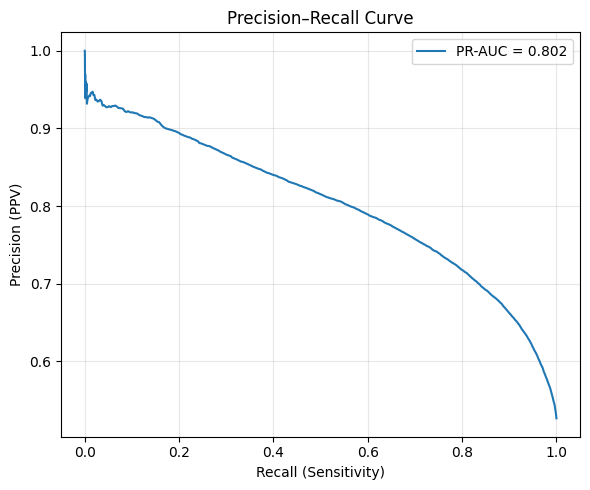

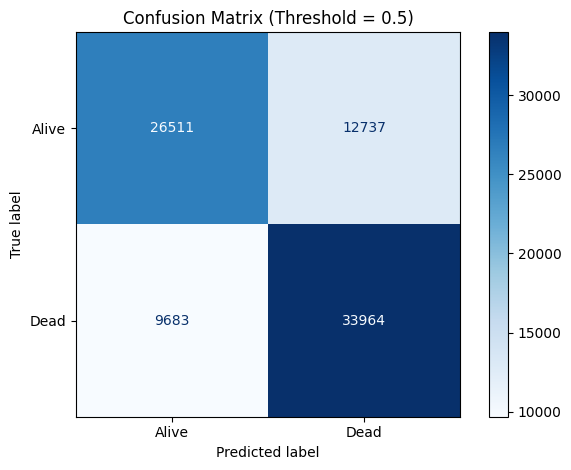

Sensitivity (Recall): 0.778
Specificity: 0.675
Precision (PPV): 0.727
Negative Predictive Value: 0.732


In [ ]:
rf = RandomForestClassifier(max_depth=None, n_estimators=500, class_weight="balanced",
                            random_state=random_state)
rf.fit(X_train_processed, y_train)

y_train_pred = rf.predict(X_train_processed)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc:.3f}")
y_test_pred = rf.predict(X_test_processed)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy: {test_acc:.3f}")
y_test_prob = rf.predict_proba(X_test_processed)[:, 1]
auc = roc_auc_score(y_test, y_test_prob)
print(f"Test ROC-AUC: {auc:.3f}")
y_test_prob = rf.predict_proba(X_test_processed)[:, 1]
pr_auc = average_precision_score(y_test, y_test_prob)
print(f"Test PR-AUC: {pr_auc:.3f}")

precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Alive", "Dead"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)   
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Precision (PPV): {ppv:.3f}")
print(f"Negative Predictive Value: {npv:.3f}")

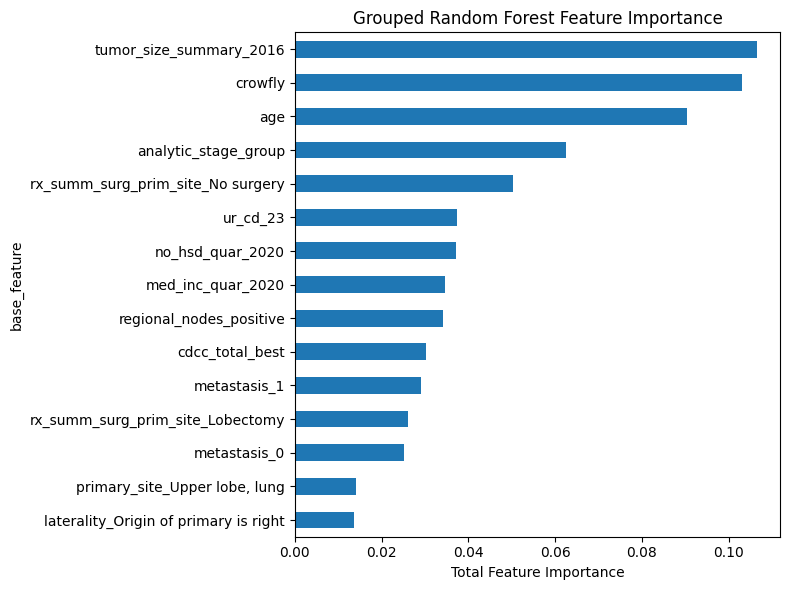

In [74]:
# Display a feature importance plot for the Random Forrest model

def get_feature_names_from_column_transformer(ct):
    feature_names = []

    for name, transformer, columns in ct.transformers_:
        if transformer == "drop":
            continue

        if transformer == "passthrough":
            feature_names.extend(columns)
            continue

        # If it's a pipeline, take the last step
        if hasattr(transformer, "named_steps"):
            transformer = transformer.named_steps[list(transformer.named_steps.keys())[-1]]

        if hasattr(transformer, "get_feature_names_out"):
            names = transformer.get_feature_names_out(columns)
            feature_names.extend(names)
        else:
            # Fallback: use column names directly
            feature_names.extend(columns)

    return np.array(feature_names)

feature_names = get_feature_names_from_column_transformer(preprocessor)
importances = rf.feature_importances_
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances
    }
).sort_values("importance", ascending=False)
importance_df["base_feature"] = (
    importance_df["feature"]
    .str.replace(r"__.*$", "", regex=True)
)
grouped_importance = (
    importance_df
    .groupby("base_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)
plt.figure(figsize=(8, 6))
grouped_importance.head(15)[::-1].plot(kind="barh")
plt.xlabel("Total Feature Importance")
plt.title("Grouped Random Forest Feature Importance")
plt.tight_layout()
plt.show()